In [7]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

# IMPORTANDO DADOS

In [8]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_ay,target_roll,target_wx,target_pitch,target_wz,target_yaw,target_wy,target_ax,target_tmp,target_az,static
0,0.0,9.737680,1.108,0.06179,0.154,-0.66750,359.823,-0.12855,-0.142746,34.5,0.144579,False
1,0.1,9.830108,1.108,-0.24387,0.154,0.19358,359.822,-0.08491,0.012837,34.7,0.203351,False
2,0.2,9.793529,1.108,0.24506,0.159,0.14292,359.822,-0.06904,0.011297,34.7,0.186503,False
3,0.3,9.795863,1.110,-0.22525,0.164,0.40590,359.821,-0.22769,0.079149,34.7,0.178510,False
4,0.4,9.839875,1.112,0.17356,0.169,0.18466,359.820,-0.10012,0.028116,34.7,0.220346,False
...,...,...,...,...,...,...,...,...,...,...,...,...
431844,43184.4,9.827430,1.415,-0.05064,0.138,-0.08800,274.238,-0.19570,0.018809,61.1,0.246922,True
431845,43184.5,9.772846,1.415,-0.11754,0.141,-0.04712,274.238,0.19151,0.036226,61.1,0.239429,True
431846,43184.6,9.758450,1.417,0.06235,0.140,0.49627,274.239,-0.14773,0.008904,61.3,0.269124,True
431847,43184.7,9.804218,1.415,0.20572,0.141,0.17441,274.239,-0.17914,-0.021418,61.3,0.274341,True


In [9]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_ay,ref_q3,ref_roll,ref_la_pos_mon_d,ref_q0,ref_wx,ref_pitch,ref_wz,ref_yaw,ref_q2,ref_wy,ref_ax,ref_q1,ref_az,ref_sample_time,static
0,0.0,-9.785,0.001270,88.636571,-0.004591,0.7156,0.006102,-0.202598,-0.004200,0.005244,-0.001234,0.013986,-0.03410,0.6985,-0.2369,905000000.0,False
1,0.1,-9.788,0.001261,88.636571,-0.005488,0.7156,-0.000854,-0.201280,-0.028648,0.005244,-0.001224,-0.000304,-0.03523,0.6986,-0.2365,5000000.0,False
2,0.2,-9.787,0.001229,88.636571,-0.006479,0.7156,0.009987,-0.196238,-0.059645,0.005026,-0.001196,-0.011900,-0.03484,0.6986,-0.2365,105000000.0,False
3,0.3,-9.785,0.001195,88.636571,-0.007552,0.7155,0.028877,-0.190566,-0.045573,0.005026,-0.001159,0.006652,-0.03261,0.6986,-0.2369,205000000.0,False
4,0.4,-9.782,0.001188,88.636571,-0.008666,0.7155,-0.000833,-0.189477,0.007231,0.005026,-0.001153,-0.001580,-0.03051,0.6986,-0.2359,305000000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431844,43184.4,-9.787,-0.019310,88.636571,-0.001588,-0.7152,0.000811,-0.399753,0.004295,2.702069,-0.013980,0.005850,-0.02464,-0.6986,-0.2317,505000000.0,True
431845,43184.5,-9.787,-0.019310,88.636571,-0.001526,-0.7152,0.008594,-0.399523,-0.004258,2.702642,-0.013980,0.005747,-0.02457,-0.6986,-0.2317,605000000.0,True
431846,43184.6,-9.787,-0.019310,88.636571,-0.001464,-0.7152,0.000384,-0.399753,0.004178,2.703215,-0.013980,0.010600,-0.02456,-0.6986,-0.2316,705000000.0,True
431847,43184.7,-9.787,-0.019310,88.636571,-0.001401,-0.7152,-0.002646,-0.399753,0.008434,2.702642,-0.013980,-0.002668,-0.02454,-0.6986,-0.2317,805000000.0,True


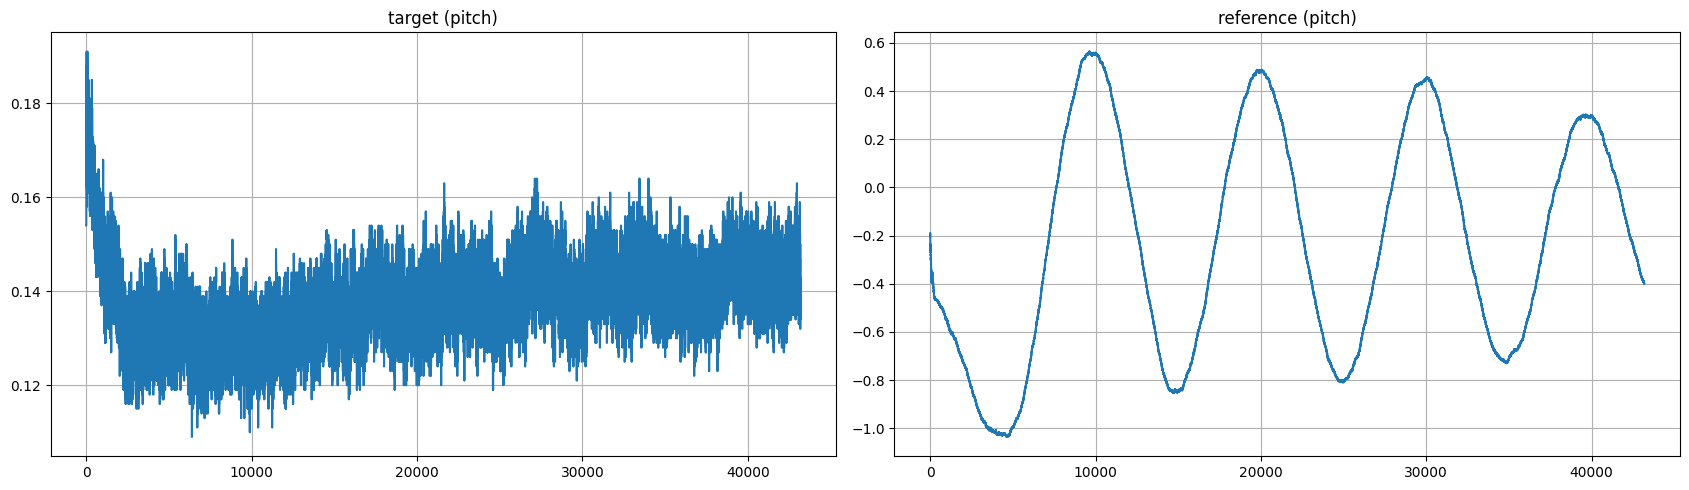

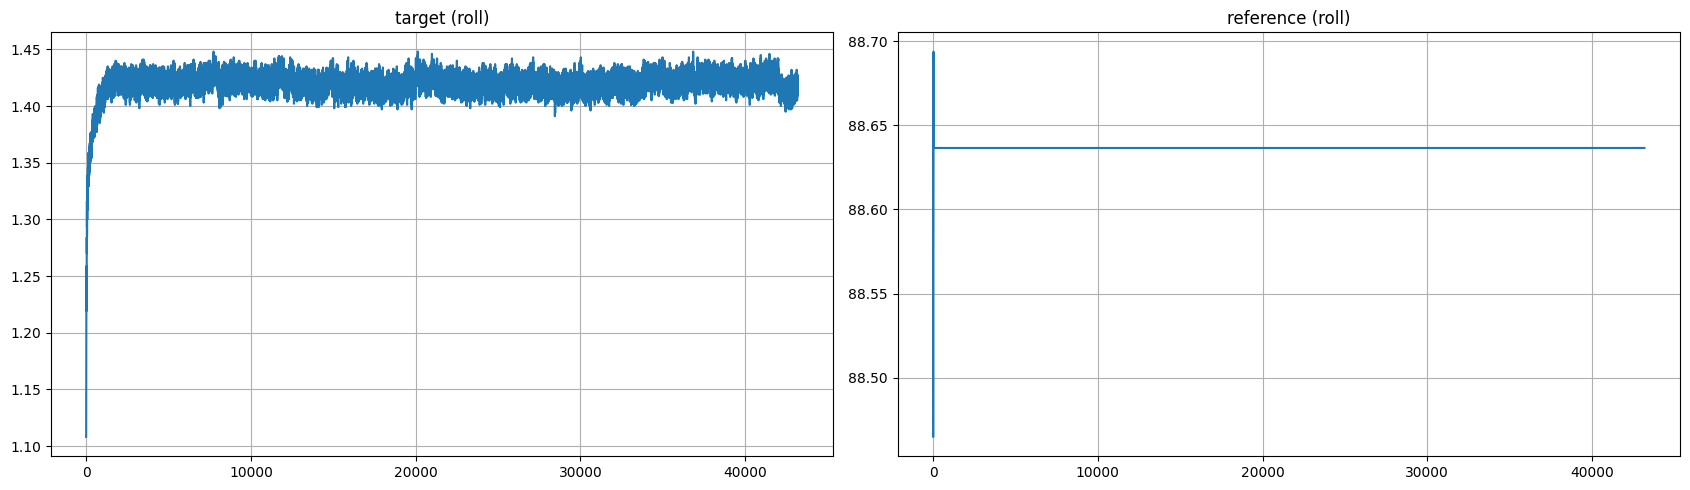

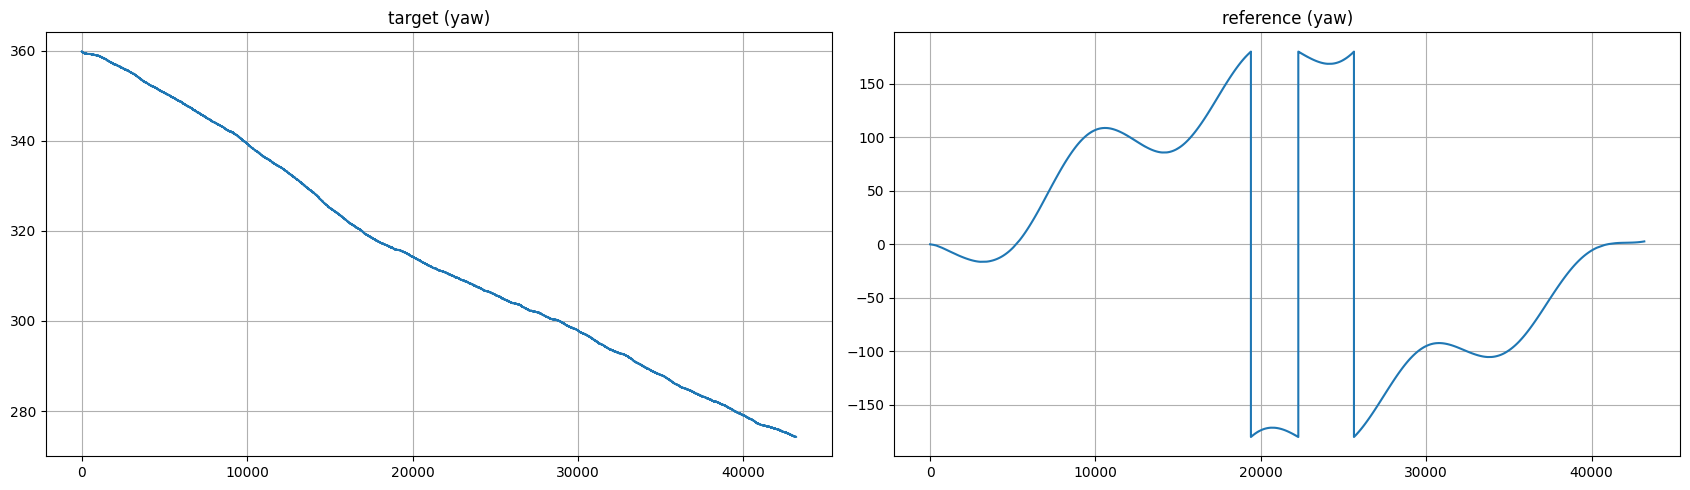

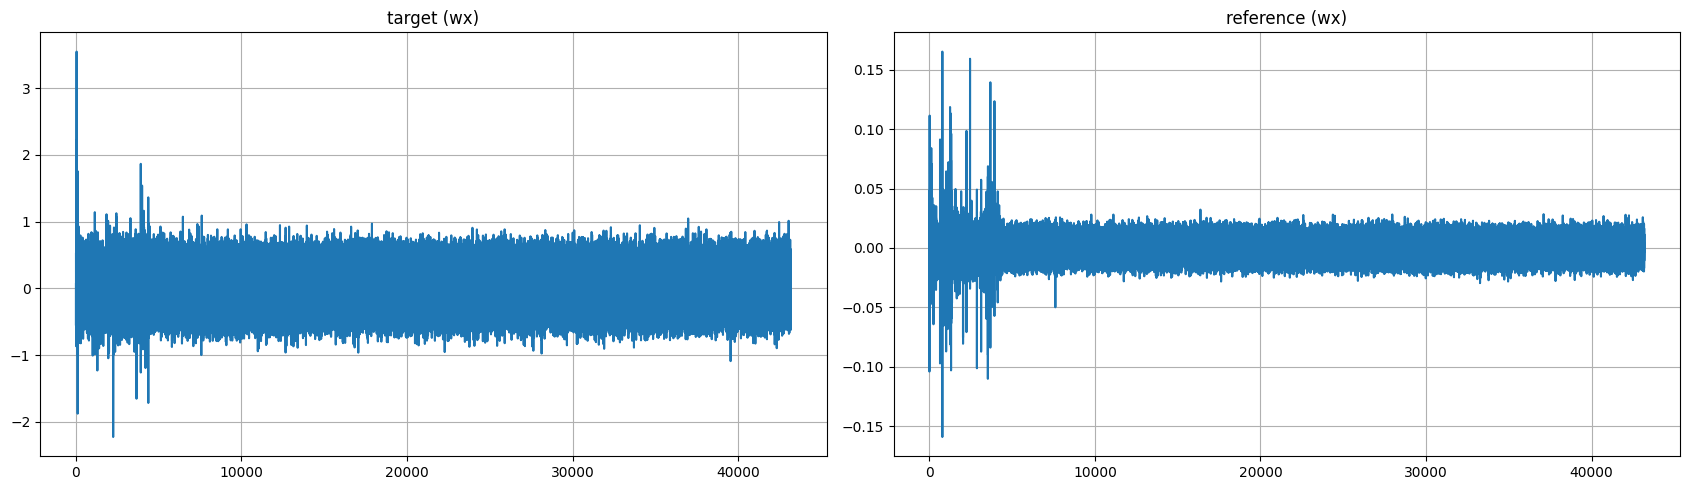

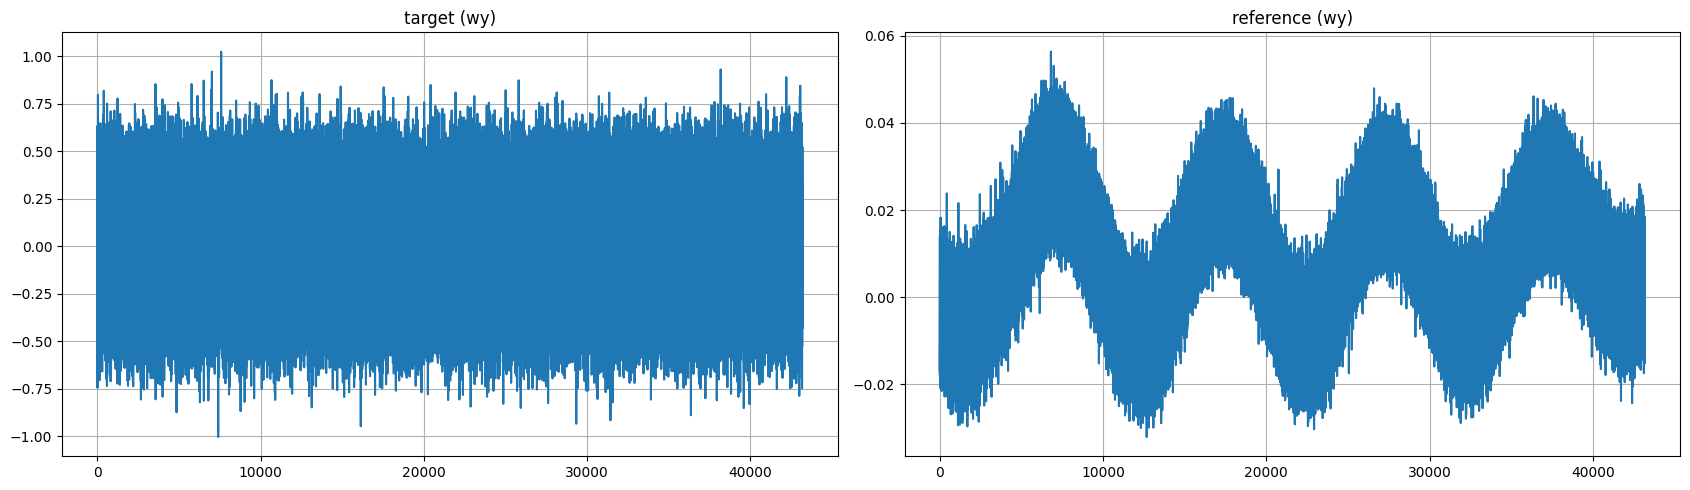

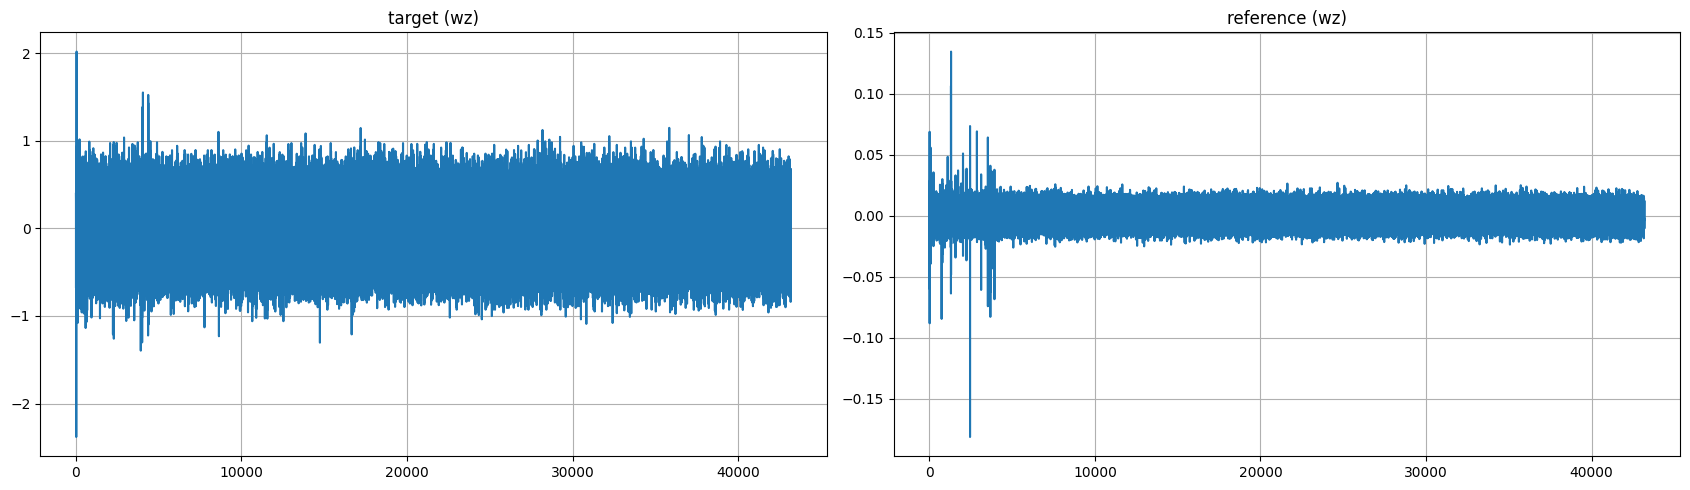

In [10]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target[f'target_{var}'], 
        f'reference ({var})': df_ref[f'ref_{var}']
    }, time=df_ref.time, figsize=(17, 5))

In [11]:
df = pd.merge_asof(df_target, df_ref, on='time', by='static', direction='nearest')
df

,time,target_ay,target_roll,target_wx,target_pitch,target_wz,target_yaw,target_wy,target_ax,target_tmp,target_az,static,ref_ay,ref_q3,ref_roll,ref_la_pos_mon_d,ref_q0,ref_wx,ref_pitch,ref_wz,ref_yaw,ref_q2,ref_wy,ref_ax,ref_q1,ref_az,ref_sample_time
0,0.0,9.737680,1.108,0.06179,0.154,-0.66750,359.823,-0.12855,-0.142746,34.5,0.144579,False,-9.785,0.001270,88.636571,-0.004591,0.7156,0.006102,-0.202598,-0.004200,0.005244,-0.001234,0.013986,-0.03410,0.6985,-0.2369,905000000.0
1,0.1,9.830108,1.108,-0.24387,0.154,0.19358,359.822,-0.08491,0.012837,34.7,0.203351,False,-9.788,0.001261,88.636571,-0.005488,0.7156,-0.000854,-0.201280,-0.028648,0.005244,-0.001224,-0.000304,-0.03523,0.6986,-0.2365,5000000.0
2,0.2,9.793529,1.108,0.24506,0.159,0.14292,359.822,-0.06904,0.011297,34.7,0.186503,False,-9.787,0.001229,88.636571,-0.006479,0.7156,0.009987,-0.196238,-0.059645,0.005026,-0.001196,-0.011900,-0.03484,0.6986,-0.2365,105000000.0
3,0.3,9.795863,1.110,-0.22525,0.164,0.40590,359.821,-0.22769,0.079149,34.7,0.178510,False,-9.785,0.001195,88.636571,-0.007552,0.7155,0.028877,-0.190566,-0.045573,0.005026,-0.001159,0.006652,-0.03261,0.6986,-0.2369,205000000.0
4,0.4,9.839875,1.112,0.17356,0.169,0.18466,359.820,-0.10012,0.028116,34.7,0.220346,False,-9.782,0.001188,88.636571,-0.008666,0.7155,-0.000833,-0.189477,0.007231,0.005026,-0.001153,-0.001580,-0.03051,0.6986,-0.2359,305000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431844,43184.4,9.827430,1.415,-0.05064,0.138,-0.08800,274.238,-0.19570,0.018809,61.1,0.246922,True,-9.787,-0.019310,88.636571,-0.001588,-0.7152,0.000811,-0.399753,0.004295,2.702069,-0.013980,0.005850,-0.02464,-0.6986,-0.2317,505000000.0
431845,43184.5,9.772846,1.415,-0.11754,0.141,-0.04712,274.238,0.19151,0.036226,61.1,0.239429,True,-9.787,-0.019310,88.636571,-0.001526,-0.7152,0.008594,-0.399523,-0.004258,2.702642,-0.013980,0.005747,-0.02457,-0.6986,-0.2317,605000000.0
431846,43184.6,9.758450,1.417,0.06235,0.140,0.49627,274.239,-0.14773,0.008904,61.3,0.269124,True,-9.787,-0.019310,88.636571,-0.001464,-0.7152,0.000384,-0.399753,0.004178,2.703215,-0.013980,0.010600,-0.02456,-0.6986,-0.2316,705000000.0
431847,43184.7,9.804218,1.415,0.20572,0.141,0.17441,274.239,-0.17914,-0.021418,61.3,0.274341,True,-9.787,-0.019310,88.636571,-0.001401,-0.7152,-0.002646,-0.399753,0.008434,2.702642,-0.013980,-0.002668,-0.02454,-0.6986,-0.2317,805000000.0


In [12]:
df.to_csv('output.csv', index=None)